<a href="https://colab.research.google.com/github/SpringBoardMentor193s/SentinelNet_Oct_Batch/blob/Vishakha/Model_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
Using pos_label for curves: 1

=== LogisticRegression ===
Weighted F1: 0.9921 | Accuracy: 0.9921 | ROC-AUC (macro OVR): nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


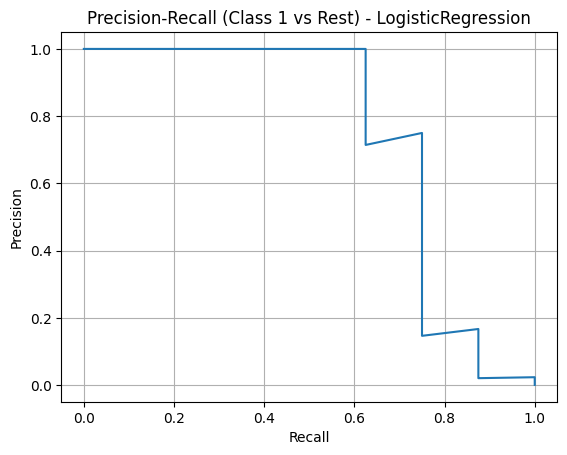

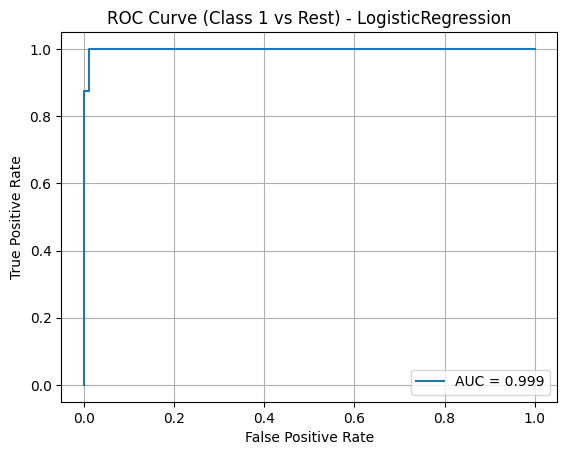

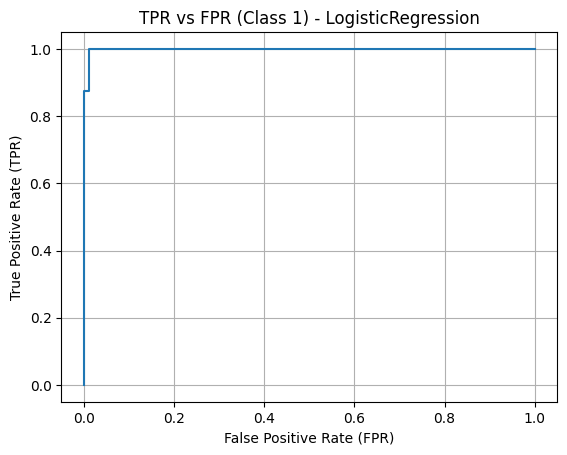

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(



=== RandomForest ===
Weighted F1: 0.9989 | Accuracy: 0.9990 | ROC-AUC (macro OVR): nan


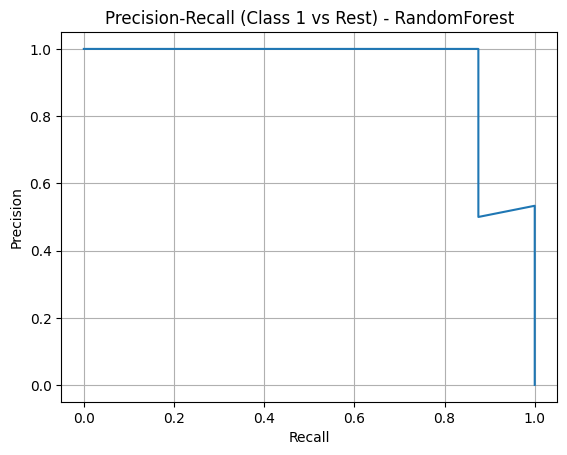

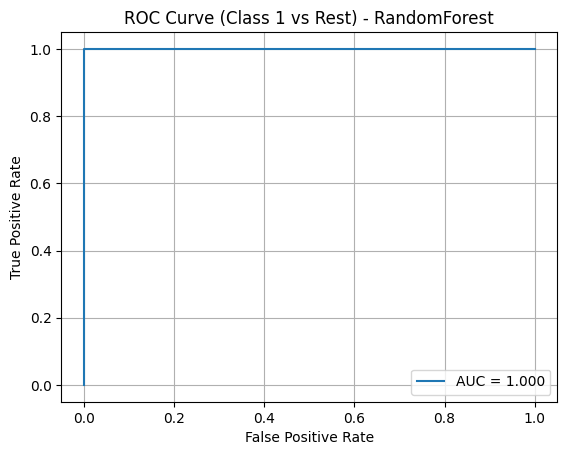

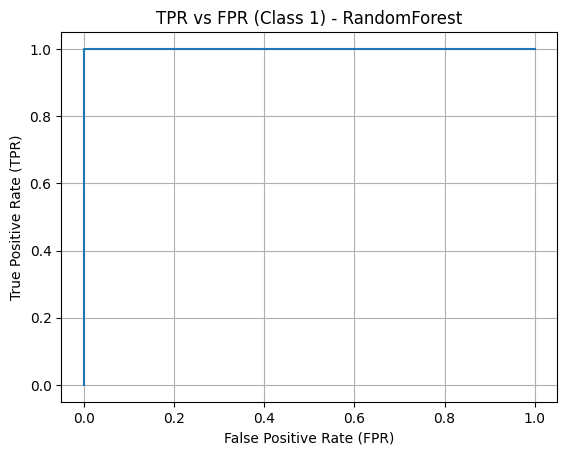


=== GradientBoosting ===
Weighted F1: 0.3687 | Accuracy: 0.3541 | ROC-AUC (macro OVR): nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


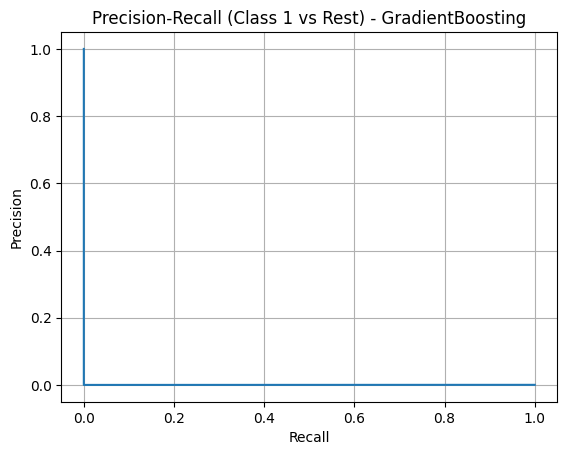

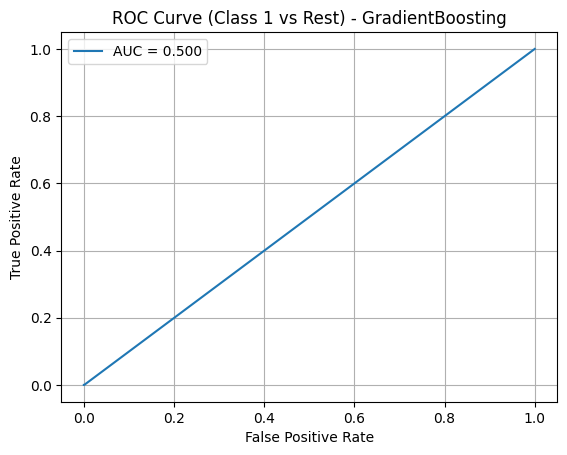

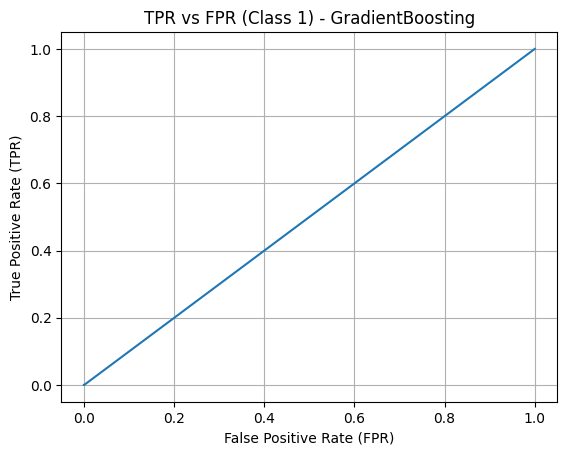


=== KNN ===
Weighted F1: 0.9975 | Accuracy: 0.9976 | ROC-AUC (macro OVR): nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


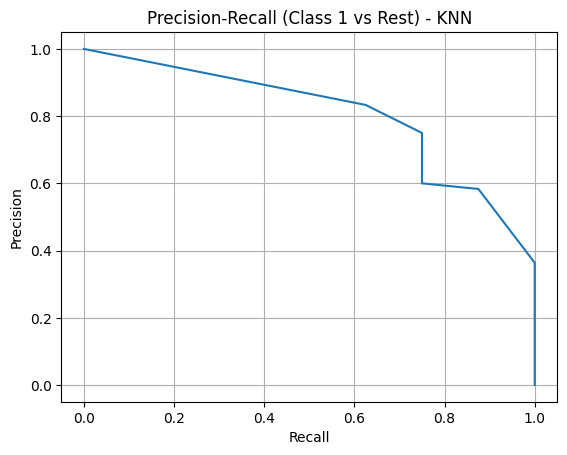

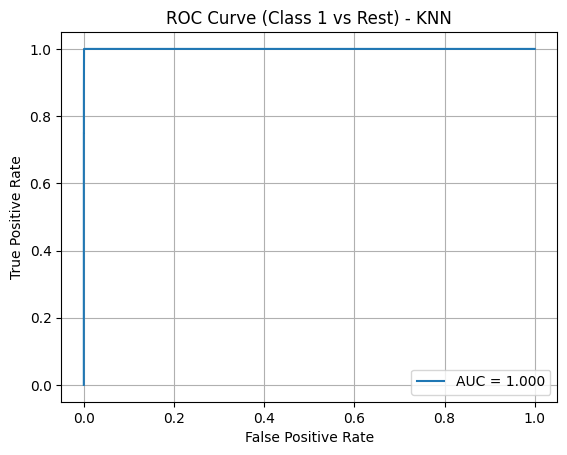

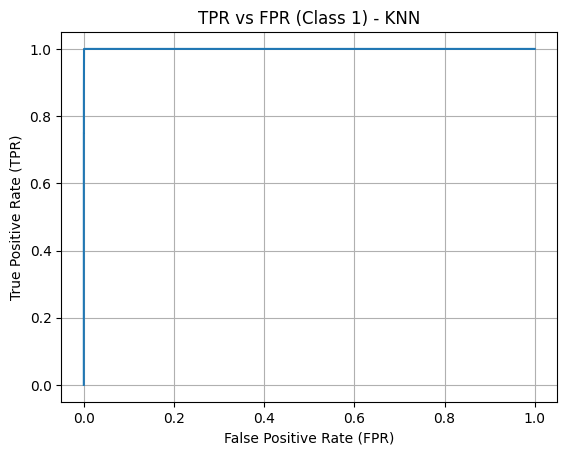


=== SVC_prob ===
Weighted F1: 0.9967 | Accuracy: 0.9968 | ROC-AUC (macro OVR): nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


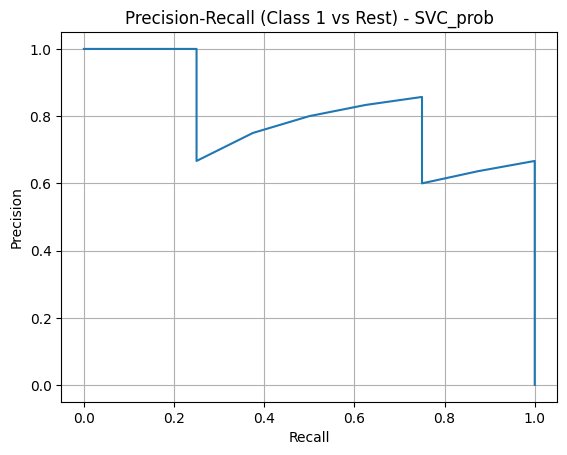

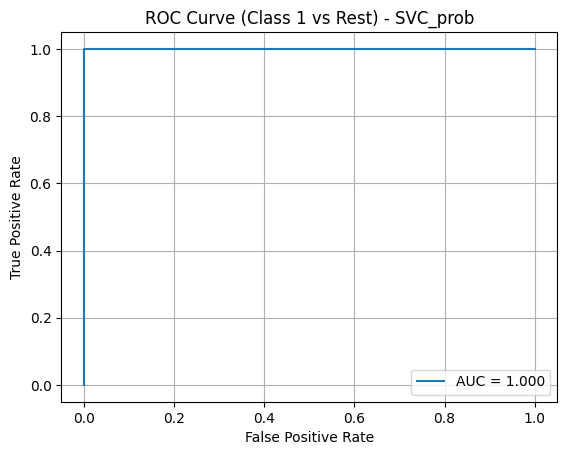

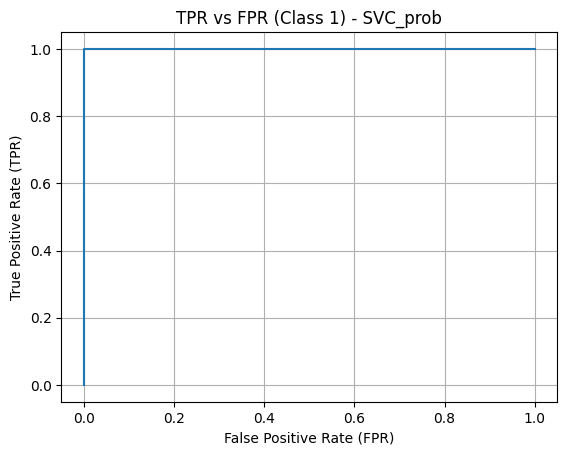

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:04:44] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost ===
Weighted F1: 0.9991 | Accuracy: 0.9991 | ROC-AUC (macro OVR): nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


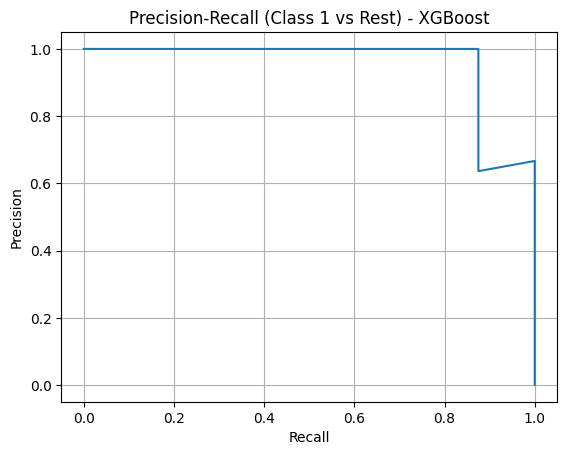

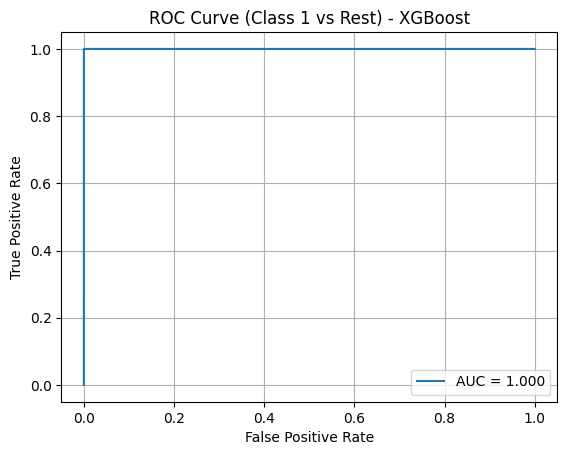

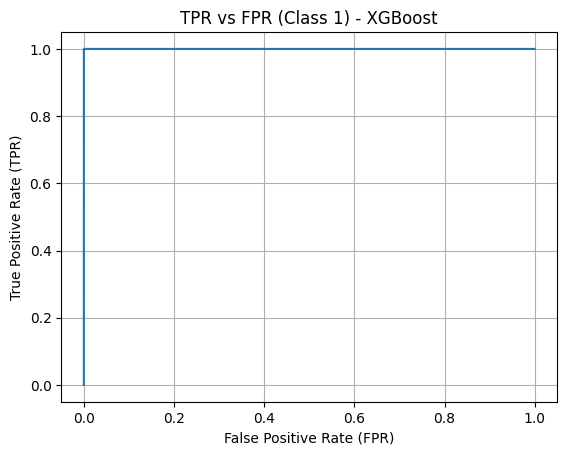


Model summary (Name, Weighted F1, Accuracy, ROC-AUC macro OVR):
('LogisticRegression', 0.9920706005486545, 0.9921254842192163, np.float64(nan))
('RandomForest', 0.9989387527272675, 0.999015685527402, np.float64(nan))
('GradientBoosting', 0.3686867518987852, 0.3541309455769353, np.float64(nan))
('KNN', 0.9974807505103988, 0.997586841938147, np.float64(nan))
('SVC_prob', 0.9966626553421395, 0.9967930399441164, np.float64(nan))
('XGBoost', 0.9990883144341808, 0.9991426938464469, np.float64(nan))


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.exceptions import NotFittedError

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# -------------------------
# 1. Load NSL-KDD Dataset
# -------------------------

columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'class', 'difficulty_level'
]

path = "/content/nslkdd_extracted/nsl-kdd/KDDTrain+.txt"
df = pd.read_csv(path, names=columns)

# -------------------------------------
# 2. Preprocess dataset
# -------------------------------------

label_enc = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = label_enc.fit_transform(df[col])

X = df.drop('class', axis=1)
y = df['class']

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

unique_labels = np.unique(y)
pos_label = 1 if 1 in unique_labels else unique_labels[0]
print("Unique labels:", unique_labels)
print("Using pos_label for curves:", pos_label)

# -------------------------------------
# helper functions
# -------------------------------------

def softmax(z):
    z = np.asarray(z)
    if z.ndim == 1:
        z -= np.max(z)
        exp = np.exp(z)
        return exp / exp.sum()
    else:
        z -= np.max(z, axis=1, keepdims=True)
        exp = np.exp(z)
        return exp / exp.sum(axis=1, keepdims=True)

def get_proba_or_score(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)

    elif hasattr(model, "decision_function"):
        dec = model.decision_function(X)
        dec = np.asarray(dec)

        if dec.ndim == 1:  # binary sigmoid
            from scipy.special import expit
            p1 = expit(dec)
            return np.vstack([1 - p1, p1]).T
        else:  # multi-class softmax
            return softmax(dec)

    else:
        raise AttributeError("Model has neither predict_proba nor decision_function.")

# -------------------------------------
# 3. Models to train
# -------------------------------------

models = [
    ("LogisticRegression", LogisticRegression(max_iter=2000)),
    ("RandomForest", RandomForestClassifier(n_estimators=200, random_state=42)),
    ("GradientBoosting", GradientBoostingClassifier(n_estimators=200, random_state=42)),
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("SVC_prob", SVC(probability=True, kernel='rbf', random_state=42)),
]

if HAS_XGB:
    models.append(("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)))

# -------------------------------------
# 4. Train, evaluate and plot per-model
# -------------------------------------

y_test_binarized = label_binarize(y_test, classes=unique_labels)
pos_index = int(np.where(unique_labels == pos_label)[0][0])

results = []

for name, clf in models:
    try:
        clf.fit(X_train, y_train)
    except Exception as e:
        print(f"Failed to fit {name}: {e}")
        continue

    y_pred = clf.predict(X_test)

    try:
        y_proba_all = get_proba_or_score(clf, X_test)
    except Exception as e:
        print(f"Could not get probabilities/scores for {name}: {e}")
        continue

    if y_proba_all.ndim == 1:
        y_proba_all = np.vstack([1 - y_proba_all, y_proba_all]).T

    f1_w = f1_score(y_test, y_pred, average='weighted')
    acc = accuracy_score(y_test, y_pred)

    try:
        auc_macro = roc_auc_score(y_test_binarized, y_proba_all, average='macro', multi_class='ovr')
    except:
        auc_macro = np.nan

    results.append((name, f1_w, acc, auc_macro))

    print(f"\n=== {name} ===")
    print(f"Weighted F1: {f1_w:.4f} | Accuracy: {acc:.4f} | ROC-AUC (macro OVR): {auc_macro:.4f}")

    y_true_pos = (y_test == pos_label).astype(int)
    y_score_pos = y_proba_all[:, pos_index]

    if len(np.unique(y_true_pos)) < 2:
        print(f"Skipping curves for {name} because pos_label={pos_label} not present in y_test.")
        continue

    # -------------------------
    # Precision-Recall Curve
    # -------------------------
    precisions, recalls, _ = precision_recall_curve(y_true_pos, y_score_pos)
    plt.plot(recalls, precisions)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall (Class {pos_label} vs Rest) - {name}")
    plt.grid(True)
    plt.show()

    # -------------------------
    # ROC Curve
    # -------------------------
    fpr, tpr, _ = roc_curve(y_true_pos, y_score_pos)
    auc_single = roc_auc_score(y_true_pos, y_score_pos)

    plt.plot(fpr, tpr, label=f"AUC = {auc_single:.3f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve (Class {pos_label} vs Rest) - {name}")
    plt.grid(True)
    plt.legend()
    plt.show()

    # -------------------------
    # ✅ TPR vs FPR Plot (added)
    # -------------------------
    plt.plot(fpr, tpr)
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title(f"TPR vs FPR (Class {pos_label}) - {name}")
    plt.grid(True)
    plt.show()

# -------------------------------------
# 5. Summary table
# -------------------------------------

print("\nModel summary (Name, Weighted F1, Accuracy, ROC-AUC macro OVR):")
for r in results:
    print(r)


F1 Score: 0.9986561097651974


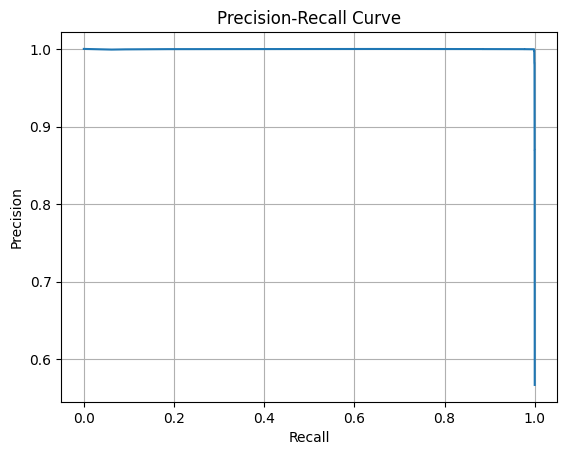

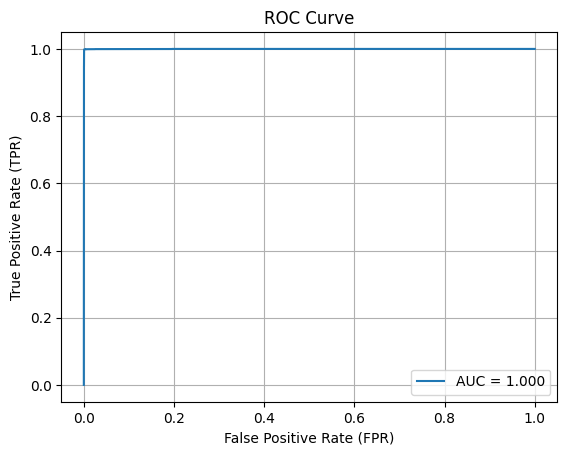

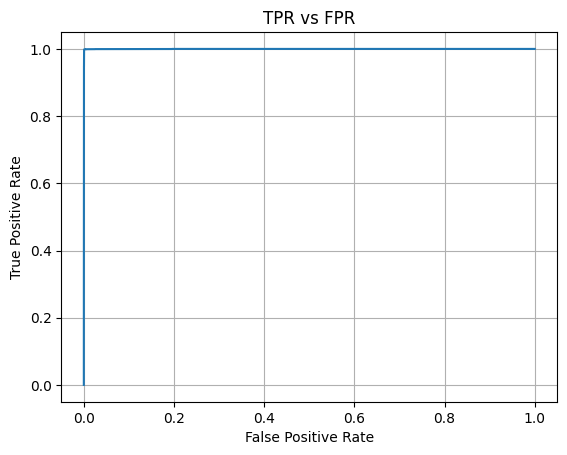

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, f1_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ----------------------------------
# 1. Load your dataset
# ----------------------------------

path = "/content/cids_extracted/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
df = pd.read_csv(path, header=0)
df.columns = df.columns.str.strip()

# ----------------------------------
# 2. Preprocessing
# ----------------------------------

label_enc = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = label_enc.fit_transform(df[col])

X = df.drop('Label', axis=1)
y = df['Label']

X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.dropna(inplace=True)
y = y[X.index]

schaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ----------------------------------
# 3. Train Model
# ----------------------------------

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# ----------------------------------
# 4. F1 Score
# ----------------------------------

f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 Score:", f1)

# ----------------------------------
# 5. Precision-Recall Curve
# ----------------------------------

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba, pos_label=df['Label'].unique()[1] if len(df['Label'].unique()) > 1 else 1)

plt.figure()
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

# ----------------------------------
# 6. ROC Curve + AUC
# ----------------------------------

fpr, tpr, thresh = roc_curve(y_test, y_proba, pos_label=df['Label'].unique()[1] if len(df['Label'].unique()) > 1 else 1)
auc = roc_auc_score(y_test == (df['Label'].unique()[1] if len(df['Label'].unique()) > 1 else 1), y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------------
# 7. TPR vs FPR
# ----------------------------------

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("TPR vs FPR")
plt.grid(True)
plt.show()

F1 Score: 0.8086642599277978


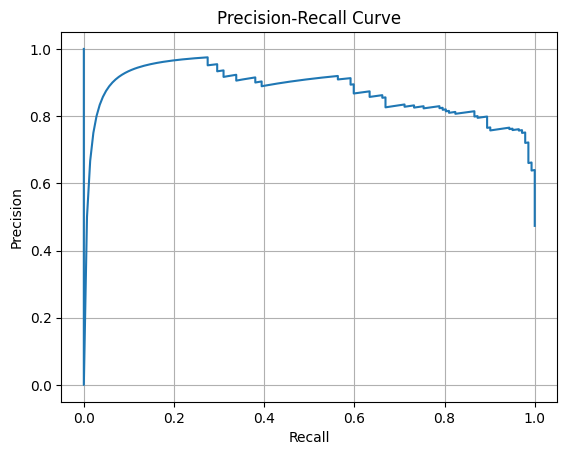

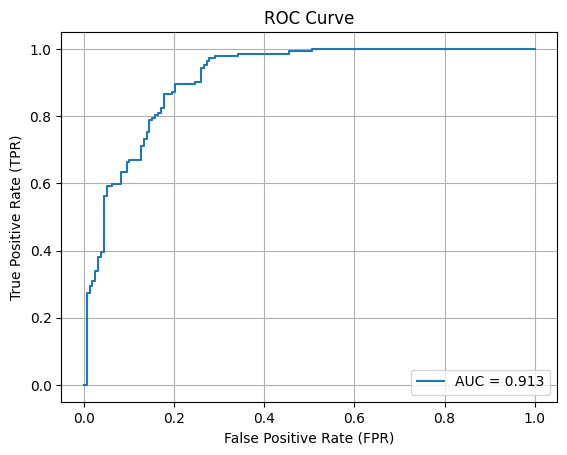

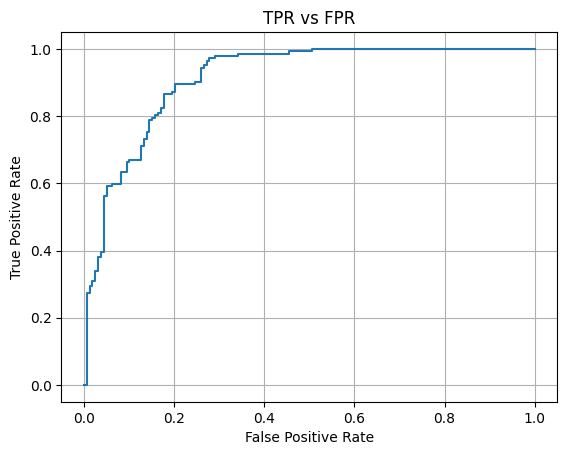

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, f1_score
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# ------------------------------
# 1. Generate Sample Binary Data
# ------------------------------
X, y = make_classification(n_samples=1000, n_features=10,
                           n_informative=5, n_redundant=2,
                           random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -------------------------
# 2. Train a Classifier
# -------------------------
model = LogisticRegression()
model.fit(X_train, y_train)

# get predicted probabilities
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# -------------------------
# 3. F1 SCORE
# -------------------------
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

# -------------------------
# 4. PRECISION-RECALL CURVE
# -------------------------
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure()
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

# -------------------------
# 5. ROC CURVE & AUC SCORE
# -------------------------
fpr, tpr, thresh = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------
# 6. TPR vs FPR Plot (same as ROC but standalone)
# -------------------------
plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("TPR vs FPR")
plt.grid(True)
plt.show()
